In [62]:
# PHASE 1: RISK ENGINE

In [63]:
# Calculating the log returns of the stocks within the portfolio

In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
import statsmodels.api as sm
import yfinance as yf

In [65]:
n = int(input("Enter the number of stocks in your portfolio: "))
tickers = []
weight = []

# Logging the stocks within the portfolio of the user; and the weightage each of them carries in the portfolio
# (I can ig optimize this by storing the stock and its weight in a pair)

for i in range(n):
    stock = input("Enter the stock in your portfolio: ")
    tickers.append(stock)
    wt = int(input("Enter its weightage within your portfolio: "))
    weight.append(wt)

total_weight = sum(weight)
if total_weight != 100:
    print(f"Warning: Your weights sum to {total_weight}%. Normalizing to 100%...")
    weight = [w / total_weight * 100 for w in weight]
print(tickers, weight)

['LULU', 'AAPL'] [50, 50]


In [115]:
data = pd.DataFrame()

# Used a for loop to fetch all the sources,
# and made it (the comment and the code)
# multi-line to avoid getting flagged by Ruff

for ticker in tickers:
    data[ticker] = yf.download(
        ticker,
        start="2015-01-01",
        auto_adjust=False,
    )["Adj Close"]

data = data.dropna()
data.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,LULU,AAPL
Date,,
2015-01-02,55.340000,24.171761
2015-01-05,55.959999,23.490801
2015-01-06,55.570000,23.493010
2015-01-07,57.650002,23.822430
2015-01-08,59.070000,24.737740


In [117]:
log_returns_of_portfolio = pd.DataFrame()
column_list = data.columns.tolist()

# Calculated the Log Return
# Not simple return coz,

# simple return = Single portfolio comparison
simple_returns_of_portfolio = data / data.shift(1) - 1

# log return = multiple portfolio comparsion

for ticker in column_list:
    log_returns_of_portfolio[ticker] = np.log(data[ticker] / data[ticker].shift(1))

log_returns_of_portfolio.head()

,LULU,AAPL
Date,,
2015-01-02,NaN,NaN
2015-01-05,0.011141,-0.028576
2015-01-06,-0.006994,0.000094
2015-01-07,0.036747,0.013925
2015-01-08,0.024333,0.037702


In [68]:
# Annualization of the data

In [118]:
annualized_return = pd.DataFrame(index=["Annualized Return"])

for ticker in column_list:
    mean_daily_log_return = log_returns_of_portfolio[ticker].mean()

    # recently learnt should prefer 252 over 250
    # for number of trading days within a year
    annualized_return[ticker] = mean_daily_log_return * 252

print(annualized_return)

                       LULU      AAPL
Annualized Return  0.044894  0.223575


In [70]:
# calculating standard deviation, variance, covariance and correlation

In [71]:
# Just now learnt the concept of "VECTORIZATION".
# Thanks to vectorization, we do not require to loop through
# all the stocks in the portfolio and calculate the variance individually,
# but rather can do the task within one single statement

# THEREFORE,

annualized_variance_of_stocks = log_returns_of_portfolio.var() * 252
annualized_standard_deviation_of_stocks = log_returns_of_portfolio.std() * np.sqrt(252)
annualized_covariance_of_stocks = log_returns_of_portfolio.cov() * 252
# Correlation is a unitless ratio and thus doesn't require to be multiplied with 250
annualized_correlation_of_stocks = log_returns_of_portfolio.corr()

print(f"Annualized std deviation: {annualized_standard_deviation_of_stocks}\n")
print(f"Annualized variance: {annualized_variance_of_stocks}\n")
print(f"Annualized covariance: {annualized_covariance_of_stocks}\n")
print(f"Annualized correlation: {annualized_correlation_of_stocks}\n")

Annualized std deviation: LULU    0.410719
AAPL    0.286773
dtype: float64

Annualized variance: LULU    0.168690
AAPL    0.082239
dtype: float64

Annualized covariance:           LULU      AAPL
LULU  0.168690  0.042296
AAPL  0.042296  0.082239

Annualized correlation:           LULU      AAPL
LULU  1.000000  0.359101
AAPL  0.359101  1.000000



In [72]:
# variance of the portfolio

In [73]:
# variance of a portfoliio, i.e.,
# ((omega1 * sigma1) + (omega2 * sigma2))^2
# =   (omega1^2 * sigma1^2) +
#     (omega2^2 * sigma2^2) +
#     (2 * omega1 * omega2 * sigma1 * sigma2)

# WHERE, omega1 = weightage of stock1 in the portfolio
#        omega2 = weightage of stock2 in the portfolio
#        sigma1 = standard deviation of stock1
#        sigma2 = standard deviation of stock

# BUT, in this scenario, we have the annual standard deviation collectively
# and thus, we can apply the formula:

# Portfolio variance = omega^T * Sigma(Σ) * omega

# WHERE,  omega = vector of weights
#         omega^T = Transposed vector of those weights
#         Sigma (Σ) = Covariance matrix (here, annualized_covariance_of_stocks)

In [74]:
weights_array = np.array(weight) / 100  # divided by 100 to get the decimal values
variance_of_portfolio = np.dot(weights_array.T, np.dot(annualized_covariance_of_stocks, weights_array))
print(f"Variance of the portfolio is: {variance_of_portfolio}")

Variance of the portfolio is: 0.08388030352606704


In [75]:
# Calculating the portfolio return

# Portfolio return = omega1 * R1 + omega2 * R2 + .....

# OR

# Portfolio return = omega^T dot-product R

# WHERE,  omega1 = weight of stock1,
#         omega2 = weight of stock2, ...
#         omega = weights vector
#         omega^T = Transposed vector of weights vector
#         R1 = return of stock1
#         R2 = return of stock2, ...
#         R = returns vector

In [76]:
individual_returns = annualized_return.iloc[0]
portfolio_return = np.dot(weights_array.T, individual_returns)
print(f"Annual portfolio return: {portfolio_return}")

Annual portfolio return: 0.14822703944567273


In [119]:
# Sharpe Ratio

# (return of stock "i" - risk-free rate) / standard deviation of stock "i"

# Other way to calculate Sharpe Ratio is:
#     Sharpe Ratio = (portfolio return - risk-free rate) / portfolio  volatility
#
# (portfolio volatility = sqrt of the variance of the portfolio)

In [78]:
us_treasury_yield = yf.download("^TNX", period="5d", auto_adjust=False)["Adj Close"]
# Cause we take risk free rate as the current yield on a 10 year US Treasury bond

risk_free_rate = float(us_treasury_yield.iloc[-1].iloc[0]) / 100
print("Current risk-free rate: ", risk_free_rate)

[*********************100%***********************]  1 of 1 completed

Current risk-free rate:  0.05270999908447266


In [79]:
sharpe_ratio = (portfolio_return - risk_free_rate) / np.sqrt(variance_of_portfolio)
print("Sharpe ratio of the portfolio is: ", sharpe_ratio)

Sharpe ratio of the portfolio is:  0.3298001588763966


In [80]:
# PHASE 2: PORTFOLIO OPTIMIZATION THEORY

In [81]:
# Markowitz Portfolio Optimization Theory
# Also calculating the variance and sharpe on each simulation

In [121]:
portfolio_returns = []
portfolio_volatilites = []

max_sharpe = -np.inf
max_sharpe_weights = None

min_variance = np.inf
min_variance_weights = None

for x in range(10000):
    # Calculating the random weights to uuse in the markowitz portfolio optimization theory
    new_weights = np.random.random(n)
    new_weights /= np.sum(new_weights)

    # Calculating and updating the minimum variance during the 10000 simulations
    variance_of_simulation = np.dot(new_weights.T, np.dot(annualized_covariance_of_stocks, new_weights))
    if variance_of_simulation < min_variance:
        min_variance = variance_of_simulation
        min_variance_weights = new_weights.copy()

    # Calculating and adding the portfolio returns and volatilities across the 10000 simulations
    portfolio_returns.append(np.sum(new_weights * log_returns_of_portfolio.mean()) * 252)
    portfolio_volatilites.append(np.sqrt(variance_of_simulation))

    # Calculating the sharpe for the simulations and updating the max sharpe
    sharpe_of_simulation = (portfolio_returns[x] - risk_free_rate) / portfolio_volatilites[x]
    if max_sharpe < sharpe_of_simulation:
        max_sharpe = sharpe_of_simulation
        max_sharpe_weights = new_weights.copy()

portfolio_returns = np.array(portfolio_returns)
portfolio_volatilites = np.array(portfolio_volatilites)

print("Max Sharpe: ", max_sharpe)
print("Max Sharpe weights: ", dict(zip(tickers, max_sharpe_weights)))
print("Minimum variance: ", min_variance)
print("Minimum variance weights: ", dict(zip(tickers, min_variance_weights)))

Max Sharpe:  0.5957736229074473
Max Sharpe weights:  {'LULU': np.float64(0.00013393765829974966), 'AAPL': np.float64(0.9998660623417003)}
Minimum variance:  0.07264735240206882
Minimum variance weights:  {'LULU': np.float64(0.24016296920336933), 'AAPL': np.float64(0.7598370307966306)}


Portfolio variance:        0.08388
Weighted annual variances: 0.06273
Diversifiable risk:        0.02115


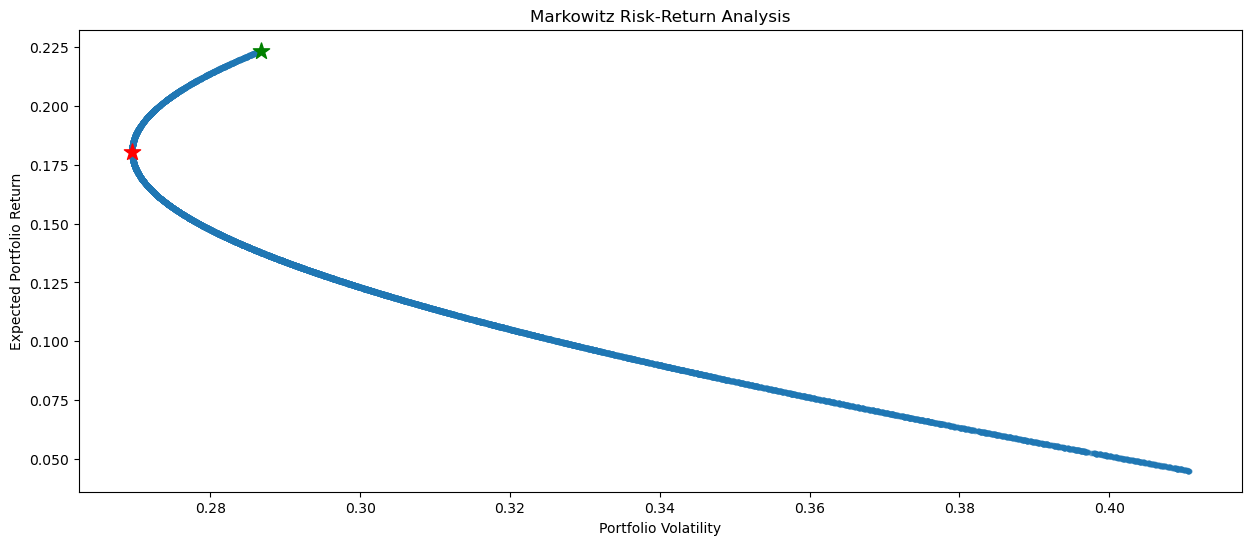

In [124]:
# Calculating the efficient frontier
plt.figure(figsize=(15, 6))
plt.scatter(portfolio_volatilites, portfolio_returns, s=10, alpha=0.5)

min_var_vol = np.sqrt(min_variance)
min_var_return = np.sum(min_variance_weights * log_returns_of_portfolio.mean()) * 252
max_sharpe_vol = np.sqrt(np.dot(max_sharpe_weights.T, np.dot(annualized_covariance_of_stocks, max_sharpe_weights)))
max_sharpe_return = np.sum(max_sharpe_weights * log_returns_of_portfolio.mean()) * 252

plt.scatter(min_var_vol, min_var_return, s=150, marker="*", color="red", label="Minimum variance")
plt.scatter(max_sharpe_vol, max_sharpe_return, s=150, marker="*", color="green", label="Max Sharpe")

plt.xlabel("Portfolio Volatility")
plt.ylabel("Expected Portfolio Return")
plt.title("Markowitz Risk-Return Analysis")

# Diversifiable risk = portfolio variance - weighted annual variances (page 20)
weighted_variances = np.sum(weights_array**2 * annualized_variance_of_stocks.values)
diversifiable_risk = variance_of_portfolio - weighted_variances

print(f"Portfolio variance:        {variance_of_portfolio:.5f}")
print(f"Weighted annual variances: {weighted_variances:.5f}")
print(f"Diversifiable risk:        {diversifiable_risk:.5f}")

plt.show()

In [84]:
sorted_indices = np.argsort(portfolio_volatilites)

sorted_volatilities = portfolio_volatilites[sorted_indices]

sorted_returns = portfolio_returns[sorted_indices]

max_return_so_far = np.maximum.accumulate(sorted_returns)

efficient_mask = sorted_returns >= max_return_so_far

efficient_volatilities = sorted_volatilities[efficient_mask]

efficient_returns = sorted_returns[efficient_mask]

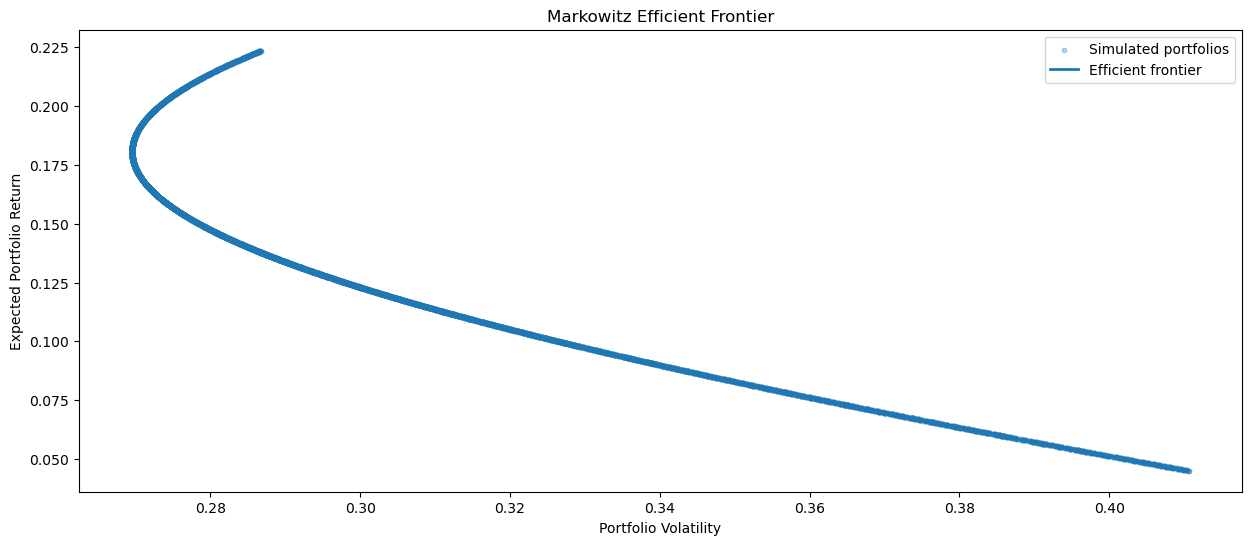

In [85]:
plt.figure(figsize=(15, 6))

# All simulated portfolios
plt.scatter(portfolio_volatilites, portfolio_returns, s=10, alpha=0.3, label="Simulated portfolios")

# Efficient frontier
plt.plot(efficient_volatilities, efficient_returns, linewidth=2, label="Efficient frontier")

plt.xlabel("Portfolio Volatility")
plt.ylabel("Expected Portfolio Return")
plt.title("Markowitz Efficient Frontier")
plt.legend()

plt.show()

In [ ]:
# CAPM

# beta = covariance with market / (variance of the market)


In [87]:
# Using the S&P 500 as the market benchmark

market_data = yf.download(
    "^GSPC",
    start="2015-01-01",
    auto_adjust=False,
)["Adj Close"]

market_data = market_data.squeeze()  # converts the dataframe with one column to a panda series

market_returns = np.log(market_data / market_data.shift(1)).dropna()

market_returns.name = "MARKET"

market_returns.head()

[*********************100%***********************]  1 of 1 completed


Date
2015-01-05   -0.018447
2015-01-06   -0.008933
2015-01-07    0.011563
2015-01-08    0.017730
2015-01-09   -0.008439
Name: MARKET, dtype: float64

In [88]:
# Calculate covariance of each stock with the market

returns_with_market = pd.concat(
    [
        log_returns_of_portfolio,
        market_returns,
    ],
    axis=1,
).dropna()

covariance_matrix_with_market = returns_with_market.cov()

covariance_with_market = covariance_matrix_with_market["MARKET"].drop("MARKET")

market_variance = market_returns.var()

beta = covariance_with_market / market_variance

print("Covariance with market:")
print(covariance_with_market)

print("\nMarket variance:")
print(market_variance)

print("\nBeta:")
print(beta)

Covariance with market:
LULU    0.000140
AAPL    0.000147
Name: MARKET, dtype: float64

Market variance:
0.00012404602764142615

Beta:
LULU    1.130422
AAPL    1.181224
Name: MARKET, dtype: float64


In [89]:
# Calculate annualized historical market return
# and risk premium and the CAPM expected return

annualized_market_return = market_returns.mean() * 252

print(f"Annualized market return: {annualized_market_return:.2%}")

market_risk_premium = annualized_market_return - risk_free_rate

capm_expected_return = risk_free_rate + beta * market_risk_premium

print("CAPM expected return:")
print(capm_expected_return)

Annualized market return: 11.39%
CAPM expected return:
LULU    0.121862
AAPL    0.124970
Name: MARKET, dtype: float64


In [90]:
# Convert annual risk-free rate to an approximate daily rate

daily_risk_free_rate = (1 + risk_free_rate) ** (1 / 252) - 1

# Calculate daily excess returns
stock_excess_returns = returns_with_market.drop(columns="MARKET") - daily_risk_free_rate
market_excess_returns = returns_with_market["MARKET"] - daily_risk_free_rate

In [91]:
# Run CAPM regression for each stock
regression_results = {}

for stock in stock_excess_returns.columns:
    X = sm.add_constant(market_excess_returns)
    y = stock_excess_returns[stock]

    model = sm.OLS(y, X).fit()

    regression_results[stock] = model

In [125]:
# Extract regression statistics
alpha = pd.Series({stock: regression_results[stock].params["const"] for stock in regression_results})

regression_beta = pd.Series({stock: regression_results[stock].params["MARKET"] for stock in regression_results})

r_squared = pd.Series({stock: regression_results[stock].rsquared for stock in regression_results})

print("Regression alpha:")
print(alpha)

print("\nRegression beta:")
print(regression_beta)

print("\nR²:")
print(r_squared)

alpha_annual = alpha * 252
idiosyncratic_share = 1 - r_squared

print("\nAnnualized alpha:")
print(alpha_annual)

print("\nShare of risk that is diversifiable (1 - R²):")
print(idiosyncratic_share)

Regression alpha:
LULU   -0.000306
AAPL    0.000390
dtype: float64

Regression beta:
LULU    1.130422
AAPL    1.181224
dtype: float64

R²:
LULU    0.236796
AAPL    0.530360
dtype: float64

Annualized alpha:
LULU   -0.077053
AAPL    0.098286
dtype: float64

Share of risk that is diversifiable (1 - R²):
LULU    0.763204
AAPL    0.469640
dtype: float64


In [93]:
# Compare beta calculated from covariance with regression beta
beta_comparison = pd.DataFrame(
    {
        "Covariance Beta": beta,
        "Regression Beta": regression_beta,
    }
)

beta_comparison["Difference"] = beta_comparison["Covariance Beta"] - beta_comparison["Regression Beta"]

beta_comparison

,Covariance Beta,Regression Beta,Difference
LULU,1.130422,1.130422,-4.440892e-16
AAPL,1.181224,1.181224,2.220446e-15


In [94]:
# Calculate annualized historical returns for each stock
annualized_stock_returns = log_returns_of_portfolio.mean() * 252

return_comparison = pd.DataFrame(
    {
        "Historical Return": annualized_stock_returns,
        "CAPM Expected Return": capm_expected_return,
    }
)

return_comparison["Difference"] = return_comparison["Historical Return"] - return_comparison["CAPM Expected Return"]

return_comparison

,Historical Return,CAPM Expected Return,Difference
LULU,0.044984,0.121862,-0.076878
AAPL,0.223498,0.124970,0.098528


In [95]:
# Calculate regression residuals
residuals = pd.DataFrame(index=returns_with_market.index)

for stock in stock_excess_returns.columns:
    residuals[stock] = regression_results[stock].resid

residuals.head()

# Summarize residual behavior
residual_summary = pd.DataFrame(
    {
        "Mean Residual": residuals.mean(),
        "Residual Std Dev": residuals.std(),
        "Min Residual": residuals.min(),
        "Max Residual": residuals.max(),
    }
)

residual_summary

,Mean Residual,Residual Std Dev,Min Residual,Max Residual
LULU,-1.727681e-18,0.022603,-0.270062,0.144985
AAPL,-8.075032e-19,0.012380,-0.084980,0.090184


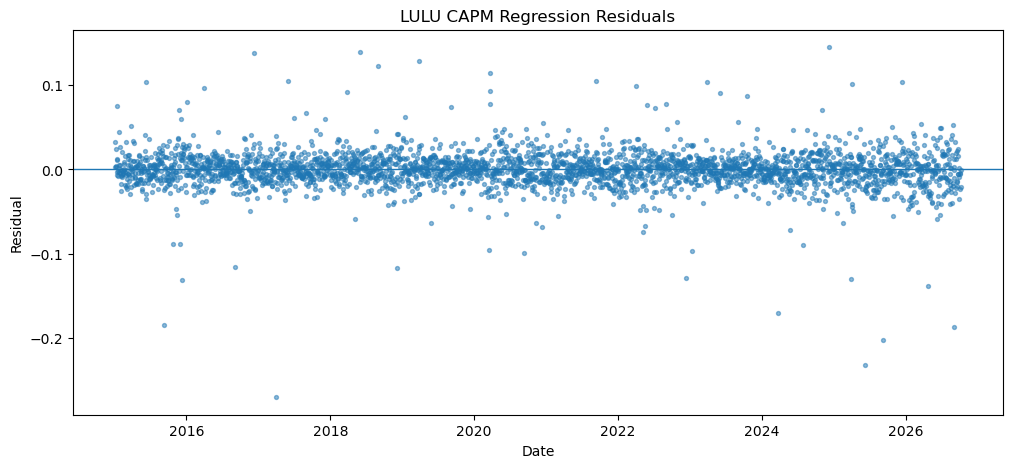

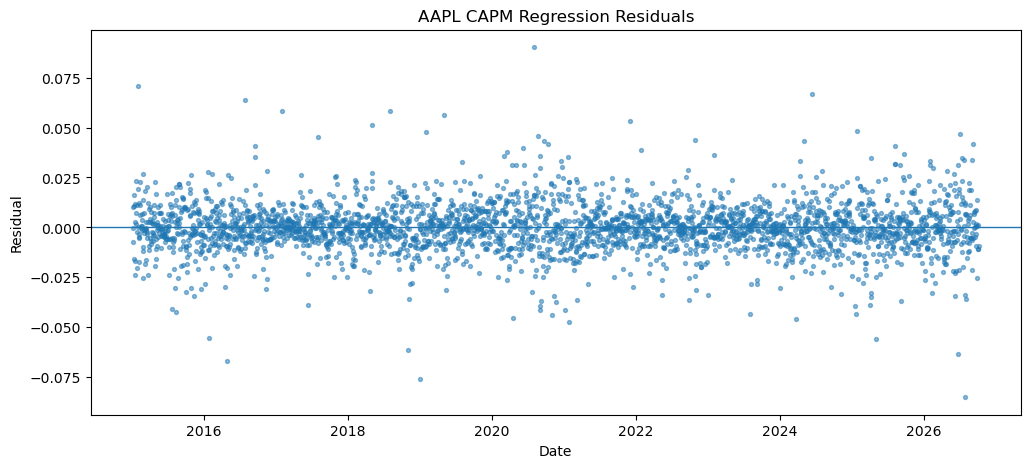

In [96]:
# Plot residuals over time
for stock in residuals.columns:
    plt.figure(figsize=(12, 5))

    plt.scatter(
        residuals.index,
        residuals[stock],
        s=8,
        alpha=0.5,
    )

    plt.axhline(
        0,
        linewidth=1,
    )

    plt.xlabel("Date")
    plt.ylabel("Residual")
    plt.title(f"{stock} CAPM Regression Residuals")

    plt.show()

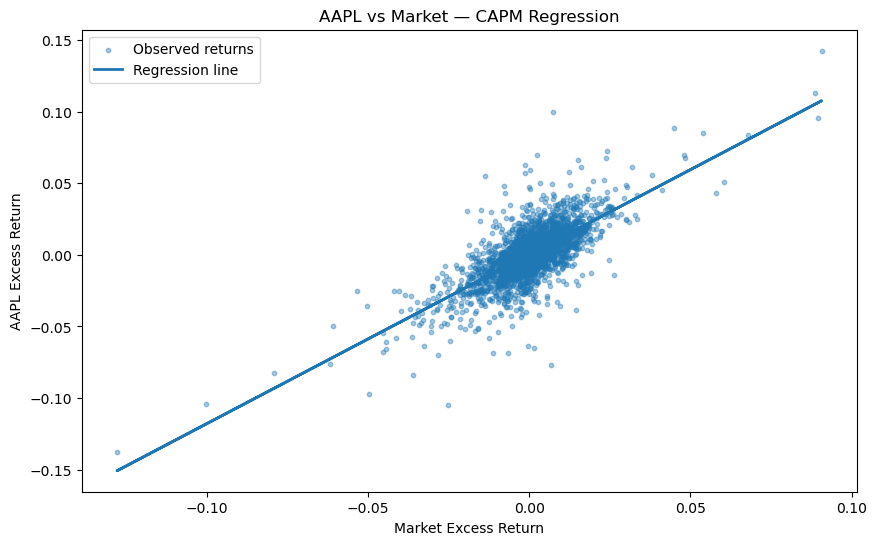

In [97]:
# Visualize the CAPM regression for AAPL
stock = "AAPL"

model = regression_results[stock]

plt.figure(figsize=(10, 6))

plt.scatter(
    market_excess_returns,
    stock_excess_returns[stock],
    s=10,
    alpha=0.4,
    label="Observed returns",
)

plt.plot(
    market_excess_returns,
    model.predict(sm.add_constant(market_excess_returns)),
    linewidth=2,
    label="Regression line",
)

plt.xlabel("Market Excess Return")
plt.ylabel(f"{stock} Excess Return")
plt.title(f"{stock} vs Market — CAPM Regression")
plt.legend()

plt.show()

In [98]:
# PHASE 4- MONTE CARLO SIMULATIONS

In [99]:
revenue_mean = log_returns_of_portfolio.mean()
revenue_std_deviation = log_returns_of_portfolio.std()
iterations = 1000

revenue = np.random.normal(loc=revenue_mean, scale=revenue_std_deviation, size=(iterations, len(log_returns_of_portfolio.columns)))
print(revenue)

[[-0.00989846  0.0076494 ]
 [ 0.04626697  0.01731675]
 [ 0.03935817  0.00143007]
 ...
 [ 0.00337103  0.01666999]
 [ 0.01904844 -0.02507666]
 [ 0.00263395 -0.00580757]]


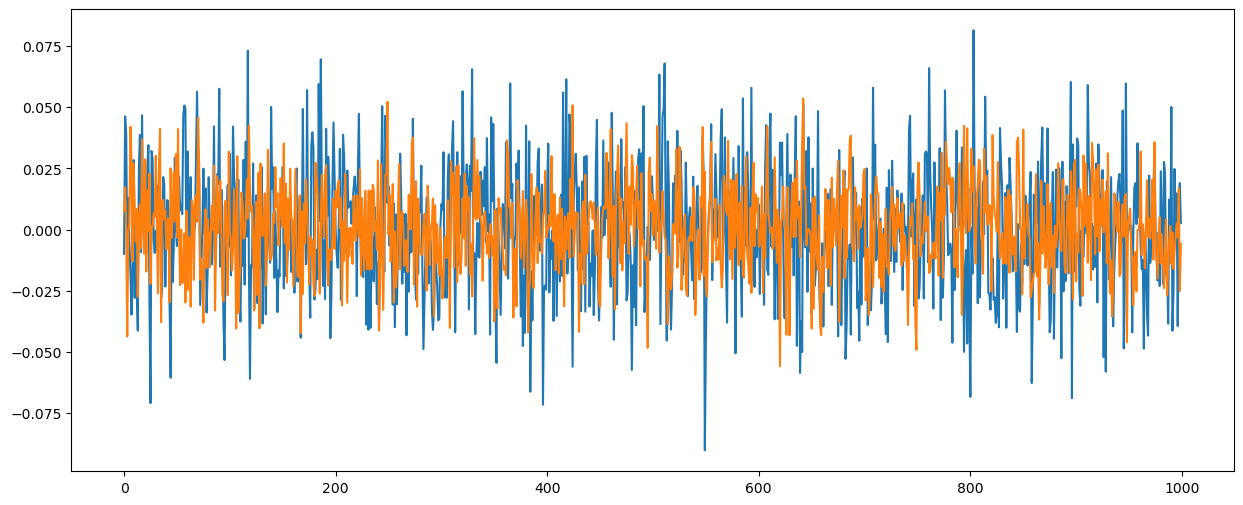

In [100]:
plt.figure(figsize=(15, 6))
plt.plot(revenue)
plt.show()

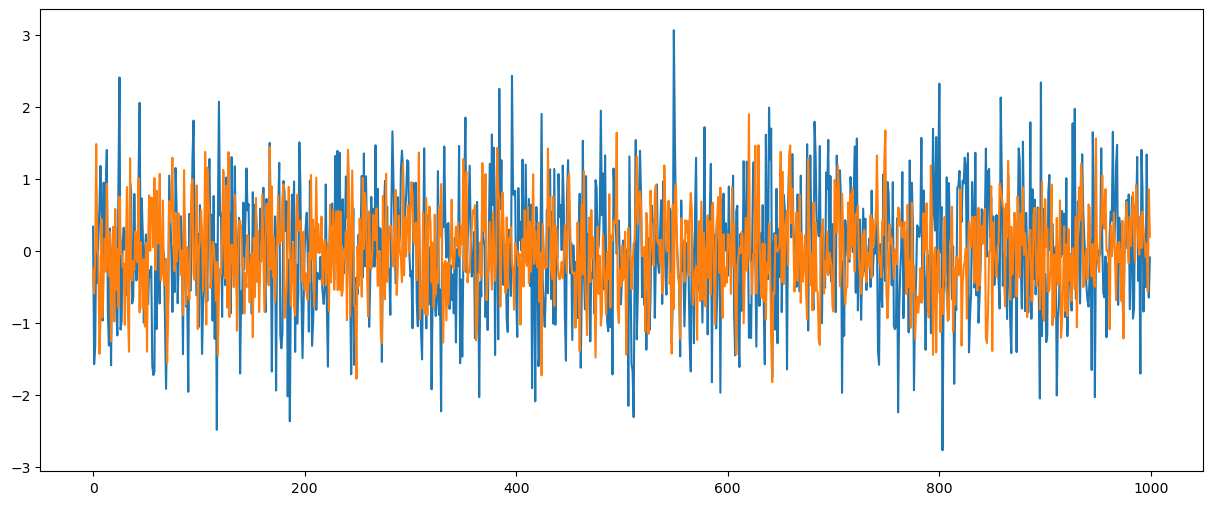

In [101]:
cogs_percentage = int(input("Enter the % of company's revenue that COGS amounts to: "))
cost_of_goods_sold = -(revenue * np.random.normal(cogs_percentage, revenue_std_deviation))

plt.figure(figsize=(15, 6))
plt.plot(cost_of_goods_sold)
plt.show()

In [102]:
gross_profit = revenue + cost_of_goods_sold
print(gross_profit)

[[ 0.32616802 -0.25234943]
 [-1.52456042 -0.57126988]
 [-1.29690592 -0.04717732]
 ...
 [-0.11108019 -0.54993363]
 [-0.6276723   0.82726505]
 [-0.08679217  0.19158846]]


In [103]:
# Price today = Price yesterday * e^( drift + random value )

# WHERE,  drift = (mu - 1/2 (sigma)^2 )
# r = ln(price today/ price yesterday)
# and e^r is a random variable;
# (one of the components of the brownian motion)


# Another formula for drift is:
#         drift = mu - 1/2 * var

# WHERE, var = variance

# daily returns = e^r
# r = drift + std * z


In [104]:
# 1. Calculate the daily mean return for each stock
daily_mu = log_returns_of_portfolio.mean()

# 2. Calculate the daily variance for each stock
daily_var = log_returns_of_portfolio.var()

# 3. Calculate daily drift using strictly daily metrics
drift = daily_mu - (0.5 * daily_var)

print("Daily Drift:\n", drift)

Daily Drift:
 LULU   -0.000156
AAPL    0.000724
dtype: float64


In [126]:
time_interval_of_forecast = 252  # one year of trading days
forecast_iterations = 10000
num_assets = len(drift)

# Random component Z (page 41)
Z = norm.ppf(np.random.rand(time_interval_of_forecast, forecast_iterations, num_assets))

# Daily standard deviation of log returns
daily_std = log_returns_of_portfolio.std().values

# Daily returns = e^(drift + stdev * Z)
daily_returns = np.exp(drift.values + daily_std * Z)

print(daily_returns)

[[[0.97927364 1.00347898]
  [1.02526113 1.01762206]
  [0.99433474 0.99564566]
  ...
  [1.03047659 1.00930888]
  [0.98652096 0.98623211]
  [1.00712558 0.9846585 ]]

 [[1.00585865 0.98945941]
  [0.983994   1.00826175]
  [1.00218285 0.98052478]
  ...
  [1.01710203 0.99532172]
  [0.99165911 0.9988311 ]
  [0.9846772  1.0014747 ]]

 [[1.01849545 1.02036883]
  [1.00159723 1.02362766]
  [0.98109427 0.99961919]
  ...
  [0.98940251 1.01562241]
  [1.04342971 1.00130147]
  [0.97616958 1.01312812]]

 ...

 [[0.95576738 1.00464341]
  [0.96598655 0.97316332]
  [1.00943407 0.96708033]
  ...
  [0.98974306 0.97800692]
  [0.99644664 1.03184112]
  [1.02147514 0.99403218]]

 [[1.01147006 1.0188425 ]
  [1.02428779 0.98322868]
  [1.02032765 1.00900932]
  ...
  [1.00990588 1.01848634]
  [1.00326829 1.00243738]
  [0.9807295  1.01236801]]

 [[1.05419541 0.99974581]
  [1.02442065 1.00762232]
  [1.00532131 1.00926596]
  ...
  [0.9771021  1.03559589]
  [0.96462496 1.02610193]
  [1.02130863 0.97248237]]]


In [127]:
# Stock price of 'i'th day = Stock price of (i-1)th day * daily return of 'i'th day
# Therefore,

# Get the most recent prices
s0 = data.iloc[-1]
print("Initial stock price:\n", s0)

# Create an empty array matching the shape of daily_returns
price_list = np.zeros_like(daily_returns)

# Set the first day's price to the current actual price
price_list[0] = s0.values

# Loop through the remaining days to calculate future prices
for t in range(1, time_interval_of_forecast):
    price_list[t] = price_list[t - 1] * daily_returns[t]

print("Final price list:\n", price_list)

Initial stock price:
 LULU     93.700798
AAPL    332.870087
Name: 2026-10-06 00:00:00, dtype: float64
Final price list:
 [[[ 93.70079803 332.87008667]
  [ 93.70079803 332.87008667]
  [ 93.70079803 332.87008667]
  ...
  [ 93.70079803 332.87008667]
  [ 93.70079803 332.87008667]
  [ 93.70079803 332.87008667]]

 [[ 94.24975784 329.36144098]
  [ 92.20102329 335.6201776 ]
  [ 93.9053327  326.38736838]
  ...
  [ 95.30327209 331.31282766]
  [ 92.91924978 332.48099582]
  [ 92.26503926 333.36096935]]

 [[ 95.99294973 336.07014857]
  [ 92.34828956 343.55009758]
  [ 92.12998409 326.26307562]
  ...
  [ 94.29329708 336.48873279]
  [ 96.95470627 332.91371024]
  [ 90.06632418 337.7373728 ]]

 ...

 [[300.58357774 362.04261771]
  [ 64.52551069 356.985058  ]
  [ 75.14596449 572.12183226]
  ...
  [117.11059583 260.15336264]
  [ 78.55998368 386.22750769]
  [ 40.62669765 265.10594816]]

 [[304.03129004 368.86440453]
  [ 66.09269244 350.9979464 ]
  [ 76.67350569 577.27626376]
  ...
  [118.27067983 264.96264

Terminal price summary
      Mean Price  Median Price  5th Percentile (Worst Case)  95th Percentile (Best Case)  Standard Deviation
LULU   98.001900     90.592593                    46.037325                   175.906014           41.400201
AAPL  415.270302    398.491362                   249.808706                   640.436551          121.163942


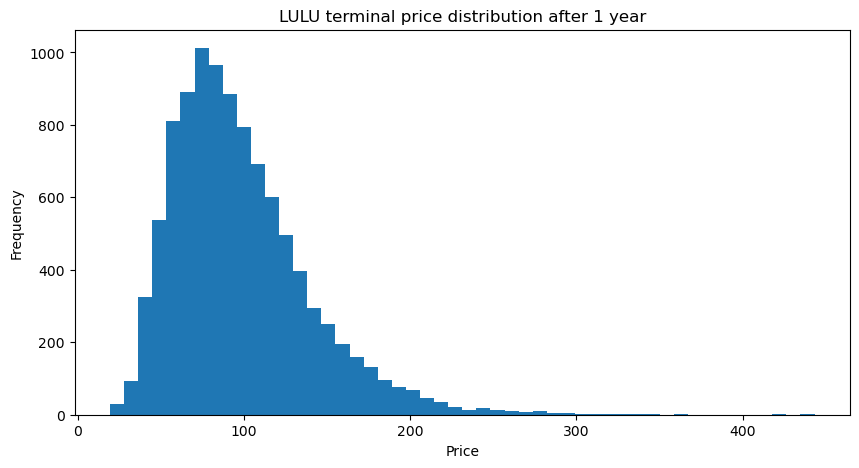

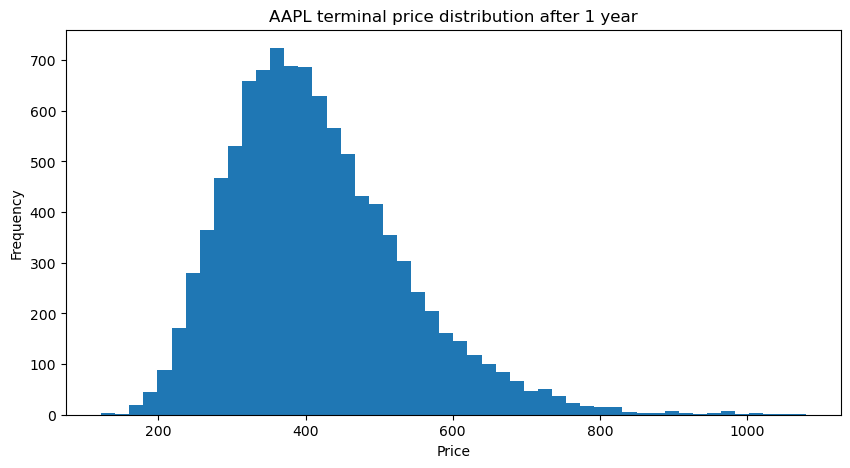

In [128]:
terminal_prices = price_list[-1]
terminal_df = pd.DataFrame(terminal_prices, columns=data.columns)

print("Terminal price summary")

summary_stats = pd.DataFrame(
    {
        "Mean Price": terminal_df.mean(),
        "Median Price": terminal_df.median(),
        "5th Percentile (Worst Case)": terminal_df.quantile(0.05),
        "95th Percentile (Best Case)": terminal_df.quantile(0.95),
        "Standard Deviation": terminal_df.std(),
    }
)
print(summary_stats.to_string())

# Terminal price distributions
for ticker in terminal_df.columns:
    plt.figure(figsize=(10, 5))
    plt.hist(terminal_df[ticker], bins=50)
    plt.title(f"{ticker} terminal price distribution after 1 year")
    plt.xlabel("Price")
    plt.ylabel("Frequency")
    plt.show()

In [129]:
weights = weights_array

# Normalize each stock to 100, then apply the weights
# (portfolio starts at 100 and moves with the weighted stock returns)
portfolio_paths = np.dot(price_list / s0.values, weights) * 100

terminal_portfolio_values = portfolio_paths[-1]

bull_threshold = np.percentile(terminal_portfolio_values, 90)  # Top 10%
bear_threshold = np.percentile(terminal_portfolio_values, 10)  # Bottom 10%

bull_paths = portfolio_paths[:, terminal_portfolio_values >= bull_threshold]
bear_paths = portfolio_paths[:, terminal_portfolio_values <= bear_threshold]
base_paths = portfolio_paths[:, (terminal_portfolio_values > bear_threshold) & (terminal_portfolio_values < bull_threshold)]

print("Scenario analysis summary:")
print(f"Total Iterations: {portfolio_paths.shape[1]}")
print(f"Bull Market Scenarios (Top 10%): {bull_paths.shape[1]} paths")
print(f"Base Case Scenarios (Middle 80%): {base_paths.shape[1]} paths")
print(f"Bear Market Scenarios (Bottom 10%): {bear_paths.shape[1]} paths")

print(f"\nAverage Terminal Value (start = 100) - Bull Case: {bull_paths[-1].mean():,.2f}")
print(f"Average Terminal Value (start = 100) - Base Case: {base_paths[-1].mean():,.2f}")
print(f"Average Terminal Value (start = 100) - Bear Case: {bear_paths[-1].mean():,.2f}")

Scenario analysis summary:
Total Iterations: 10000
Bull Market Scenarios (Top 10%): 1000 paths
Base Case Scenarios (Middle 80%): 8000 paths
Bear Market Scenarios (Bottom 10%): 1000 paths

Average Terminal Value (start = 100) - Bull Case: 172.59
Average Terminal Value (start = 100) - Base Case: 112.60
Average Terminal Value (start = 100) - Bear Case: 73.32


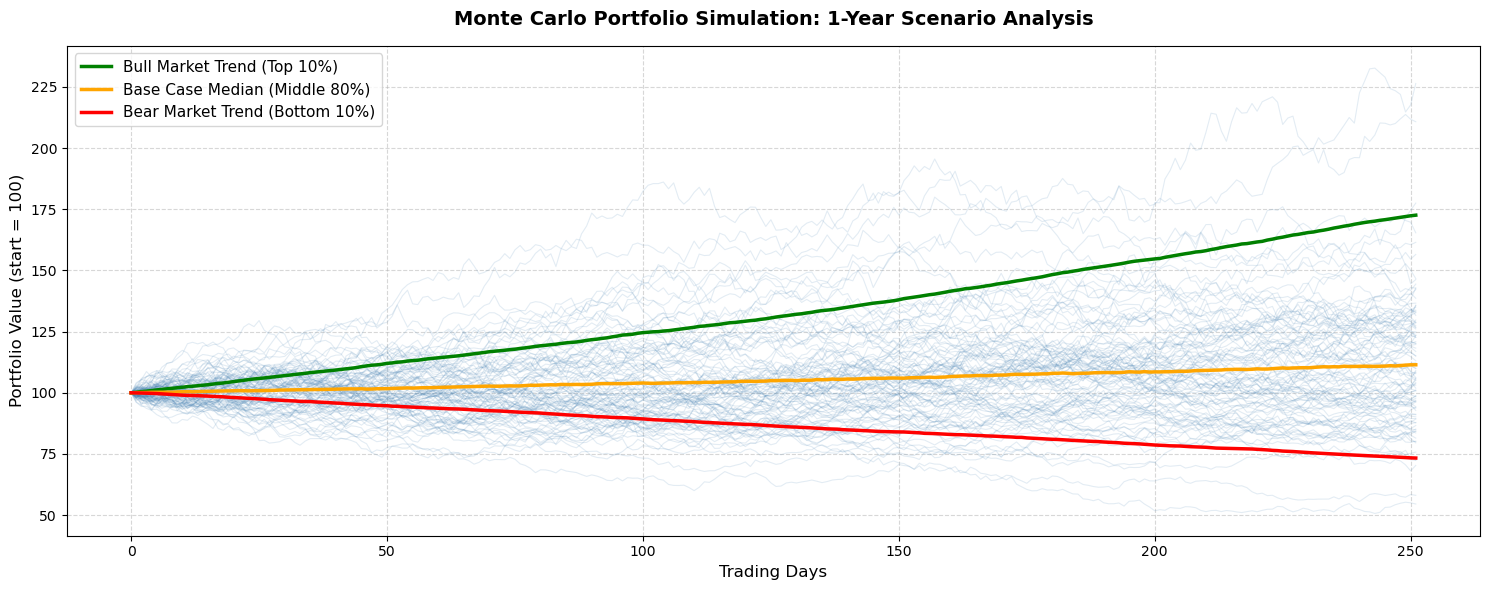

In [133]:
plt.figure(figsize=(15, 6))

# Plotting individual iterations or a subset of portfolio paths
# portfolio_paths shape is (10000, 50) -> 10,000 time steps, 50 iterations
time_axis = np.arange(portfolio_paths.shape[0])

# Plotting a subset of base paths in light grey/blue for background context
plt.plot(time_axis, portfolio_paths[:, :100], color="steelblue", alpha=0.15, linewidth=0.8)

# Plotting specific scenario averages or sample paths to highlight outcomes
# Calculate mean trajectories for visual clarity
mean_bull_path = bull_paths.mean(axis=1)
mean_bear_path = bear_paths.mean(axis=1)
median_base_path = np.median(base_paths, axis=1)

plt.plot(time_axis, mean_bull_path, color="green", linewidth=2.5, label="Bull Market Trend (Top 10%)")
plt.plot(time_axis, median_base_path, color="orange", linewidth=2.5, label="Base Case Median (Middle 80%)")
plt.plot(time_axis, mean_bear_path, color="red", linewidth=2.5, label="Bear Market Trend (Bottom 10%)")

plt.title("Monte Carlo Portfolio Simulation: 1-Year Scenario Analysis", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Trading Days", fontsize=12)
plt.ylabel("Portfolio Value (start = 100)", fontsize=12)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [110]:
# PHASE 5 - DERIVATIVES

In [111]:
def black_scholes_pricing(S, K, T, r, sigma, option_type="call"):
    # Calculate d1 and d2 components of the Black-Scholes formula
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "call":
        # Call option pricing formula
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        # Put option pricing formula
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("option_type must be either 'call' or 'put'")

    return price

In [134]:
tickers = data.columns
strike_offset = 1.05  # strike 5% above the current price (out-of-the-money for the call)
time_to_maturity = 1.0  # 1 year expiration

print("Black Scholes results: ")

for ticker in tickers:
    current_s = data[ticker].iloc[-1]
    strike_price = current_s * strike_offset
    stdev = annualized_standard_deviation_of_stocks[ticker]

    call_price = black_scholes_pricing(S=current_s, K=strike_price, T=time_to_maturity, r=risk_free_rate, sigma=stdev, option_type="call")
    put_price = black_scholes_pricing(S=current_s, K=strike_price, T=time_to_maturity, r=risk_free_rate, sigma=stdev, option_type="put")

    print(f"\nTicker: {ticker}")
    print(f"  Current Price (S):      ${current_s:,.2f}")
    print(f"  Strike Price (K):       ${strike_price:,.2f}")
    print(f"  Annualized Volatility:  {stdev:.4%}")
    print(f"  European Call Price:    ${call_price:,.2f}")
    print(f"  European Put Price:     ${put_price:,.2f}")

Black Scholes results: 

Ticker: LULU
  Current Price (S):      $93.70
  Strike Price (K):       $98.39
  Annualized Volatility:  41.0719%
  European Call Price:    $15.40
  European Put Price:     $15.03

Ticker: AAPL
  Current Price (S):      $332.87
  Strike Price (K):       $349.51
  Annualized Volatility:  28.6773%
  European Call Price:    $38.53
  European Put Price:     $37.23


In [113]:
# Monte Carlo option pricing

Comparison between Monte-Carlo and Black-Scholes results: 

Ticker: LULU
  [Call] Black-Scholes: $15.40 | Monte Carlo: $15.00
  [Put]  Black-Scholes: $15.03 | Monte Carlo: $15.32


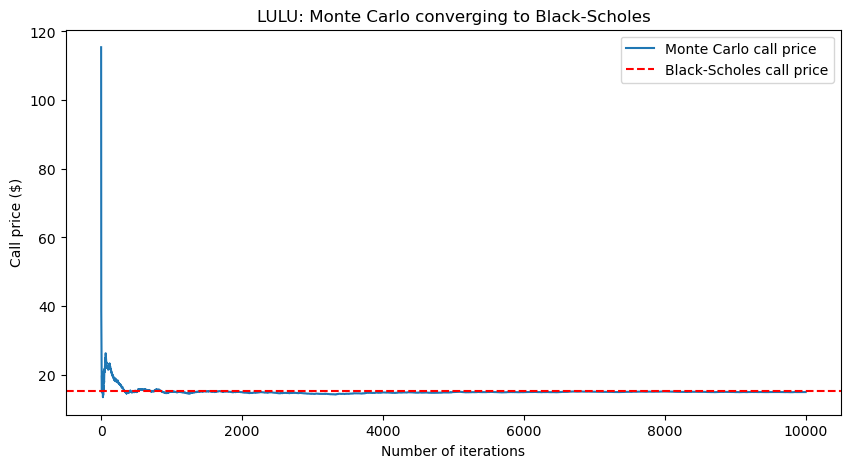


Ticker: AAPL
  [Call] Black-Scholes: $38.53 | Monte Carlo: $38.72
  [Put]  Black-Scholes: $37.23 | Monte Carlo: $37.27


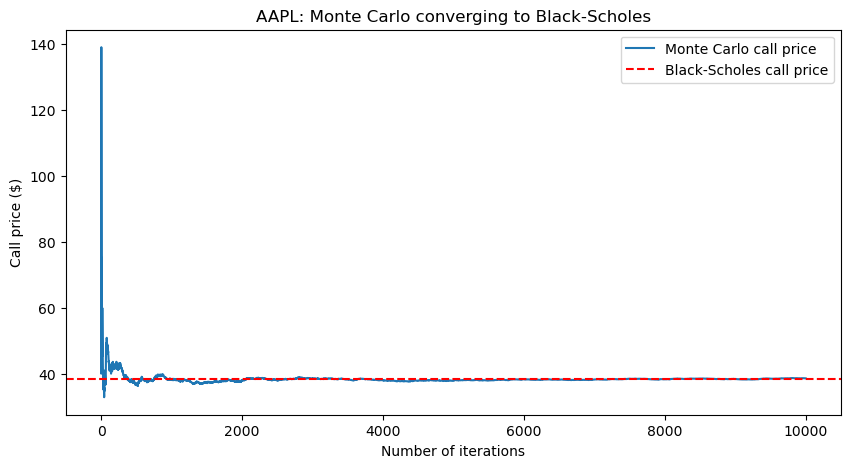

In [137]:
r = risk_free_rate
T = 1.0
t_intervals = 250
delta_t = T / t_intervals
iterations = 10000

print("Comparison between Monte-Carlo and Black-Scholes results: ")
bs_call_list, mc_call_list, bs_put_list, mc_put_list = [], [], [], []

for ticker in tickers:
    S0 = data[ticker].iloc[-1]
    K = S0 * 1.05
    stdev = annualized_standard_deviation_of_stocks[ticker]  # annual, as on page 47

    # Euler discretization (page 47)
    Z = np.random.standard_normal((t_intervals + 1, iterations))
    S = np.zeros_like(Z)
    S[0] = S0
    for t in range(1, t_intervals + 1):
        S[t] = S[t - 1] * np.exp((r - 0.5 * stdev**2) * delta_t + stdev * delta_t**0.5 * Z[t])

    # Payoffs, then C = e^(-rT) * sum(p) / iterations (page 48)
    call_payoffs = np.maximum(S[-1] - K, 0)
    put_payoffs = np.maximum(K - S[-1], 0)
    mc_call = np.exp(-r * T) * np.sum(call_payoffs) / iterations
    mc_put = np.exp(-r * T) * np.sum(put_payoffs) / iterations

    bs_call = black_scholes_pricing(S0, K, T, r, stdev, "call")
    bs_put = black_scholes_pricing(S0, K, T, r, stdev, "put")

    print(f"\nTicker: {ticker}")
    print(f"  [Call] Black-Scholes: ${bs_call:,.2f} | Monte Carlo: ${mc_call:,.2f}")
    print(f"  [Put]  Black-Scholes: ${bs_put:,.2f} | Monte Carlo: ${mc_put:,.2f}")

    bs_call_list.append(bs_call)
    mc_call_list.append(mc_call)
    bs_put_list.append(bs_put)
    mc_put_list.append(mc_put)

    # Convergence plot: running average of the discounted call payoffs
    running_mc_call = np.exp(-r * T) * np.cumsum(call_payoffs) / np.arange(1, iterations + 1)

    plt.figure(figsize=(10, 5))
    plt.plot(running_mc_call, label="Monte Carlo call price")
    plt.axhline(bs_call, color="red", linestyle="--", label="Black-Scholes call price")
    plt.title(f"{ticker}: Monte Carlo converging to Black-Scholes")
    plt.xlabel("Number of iterations")
    plt.ylabel("Call price ($)")
    plt.legend()
    plt.show()

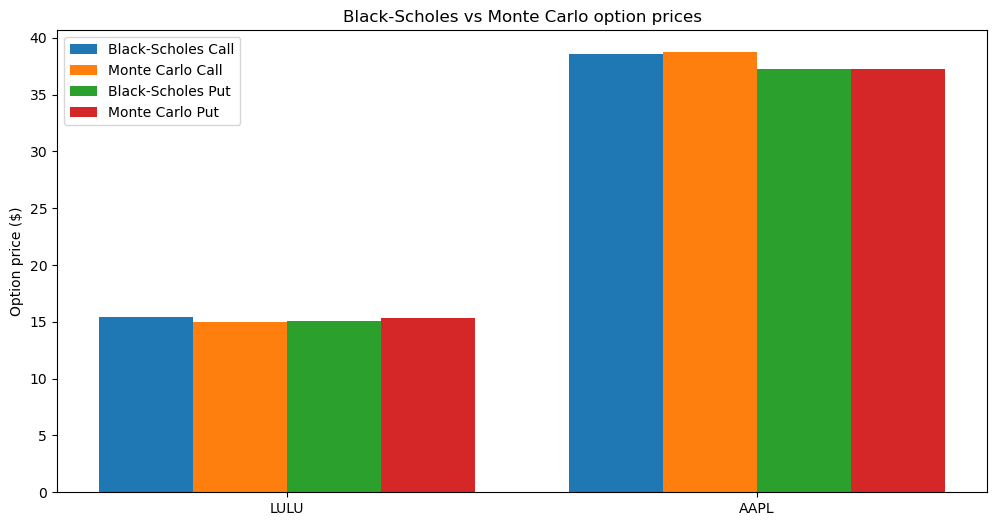

In [138]:
# Bar chart: Black-Scholes vs Monte Carlo
x = np.arange(len(tickers))
width = 0.2

plt.figure(figsize=(12, 6))
plt.bar(x - 1.5 * width, bs_call_list, width, label="Black-Scholes Call")
plt.bar(x - 0.5 * width, mc_call_list, width, label="Monte Carlo Call")
plt.bar(x + 0.5 * width, bs_put_list, width, label="Black-Scholes Put")
plt.bar(x + 1.5 * width, mc_put_list, width, label="Monte Carlo Put")

plt.xticks(x, tickers)
plt.ylabel("Option price ($)")
plt.title("Black-Scholes vs Monte Carlo option prices")
plt.legend()
plt.show()